# 03 · Participant-disjoint multimodal modeling

The goal is to compare an inexpensive behavior-only sensing strategy with physiology-only and combined models.

- Validation: leave-one-subject-out (25 folds)
- Pipeline inside every training fold: median imputation → standardization → class-balanced L2 logistic regression
- Metrics: balanced accuracy, macro-F1, ROC-AUC, sensitivity, specificity
- Targets: three-class experimental condition (primary) and Neutral versus stressor (supplementary)

The binary target describes the manipulated condition. It is not a direct minute-specific “high workload” label.

In [1]:
from pathlib import Path
import sys
import pandas as pd

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT / "src"))
from modeling import run
run()
print("LOSO outputs regenerated; preprocessing was fitted inside each training fold.")

LOSO outputs regenerated; preprocessing was fitted inside each training fold.


## Cross-participant performance

In [2]:
summary = pd.read_csv(ROOT / "tables" / "model_summary_metrics.csv")
summary.pivot_table(index=["target", "metric"], columns="feature_set", values="mean").round(3)

Out[0]: 
feature_set                              Behavior only  ...  Physiology only
target                metric                            ...                 
Neutral vs stressor   balanced_accuracy          0.575  ...            0.571
                      macro_f1                   0.555  ...            0.485
                      roc_auc                    0.590  ...            0.610
Three-class condition balanced_accuracy          0.399  ...            0.385
                      macro_f1                   0.382  ...            0.285
                      roc_auc                    0.573  ...            0.566

[6 rows x 3 columns]


In [3]:
summary[summary.target.eq("Neutral vs stressor")][
    ["feature_set", "metric", "mean", "CI_low", "CI_high"]
].round(3)

Out[0]: 
        feature_set             metric   mean  CI_low  CI_high
9     Behavior only  balanced_accuracy  0.575   0.542    0.606
10    Behavior only           macro_f1  0.555   0.519    0.586
11    Behavior only            roc_auc  0.590   0.550    0.626
12         Combined  balanced_accuracy  0.587   0.548    0.629
13         Combined           macro_f1  0.544   0.497    0.594
14         Combined            roc_auc  0.638   0.578    0.694
15  Physiology only  balanced_accuracy  0.571   0.511    0.632
16  Physiology only           macro_f1  0.485   0.412    0.562
17  Physiology only            roc_auc  0.610   0.509    0.707


## Does physiology add enough value?

In [4]:
comparison = pd.read_csv(ROOT / "tables" / "model_feature_set_comparisons.csv")
comparison.round(3)

Out[0]: 
                  target                comparison  ... CI_low  CI_high
0  Three-class condition  Combined - Behavior only  ... -0.018    0.041
1  Three-class condition  Combined - Behavior only  ... -0.041    0.024
2  Three-class condition  Combined - Behavior only  ... -0.008    0.060
3    Neutral vs stressor  Combined - Behavior only  ... -0.024    0.048
4    Neutral vs stressor  Combined - Behavior only  ... -0.057    0.034
5    Neutral vs stressor  Combined - Behavior only  ... -0.005    0.097

[6 rows x 6 columns]


Combined sensing improves the mean ROC-AUC for Neutral versus stressor by 0.048 over behavior only, but the participant-bootstrap interval crosses zero. Balanced-accuracy gain is only 0.012 and is also uncertain. With 52.9% HR/RMSSD missingness, the current evidence does not justify physiology as a required product sensor.

The behavior-only model is modestly above chance, but it is not accurate enough for autonomous notification suppression. A defensible use would be a weak context signal combined with user control and a prospective randomized policy test.

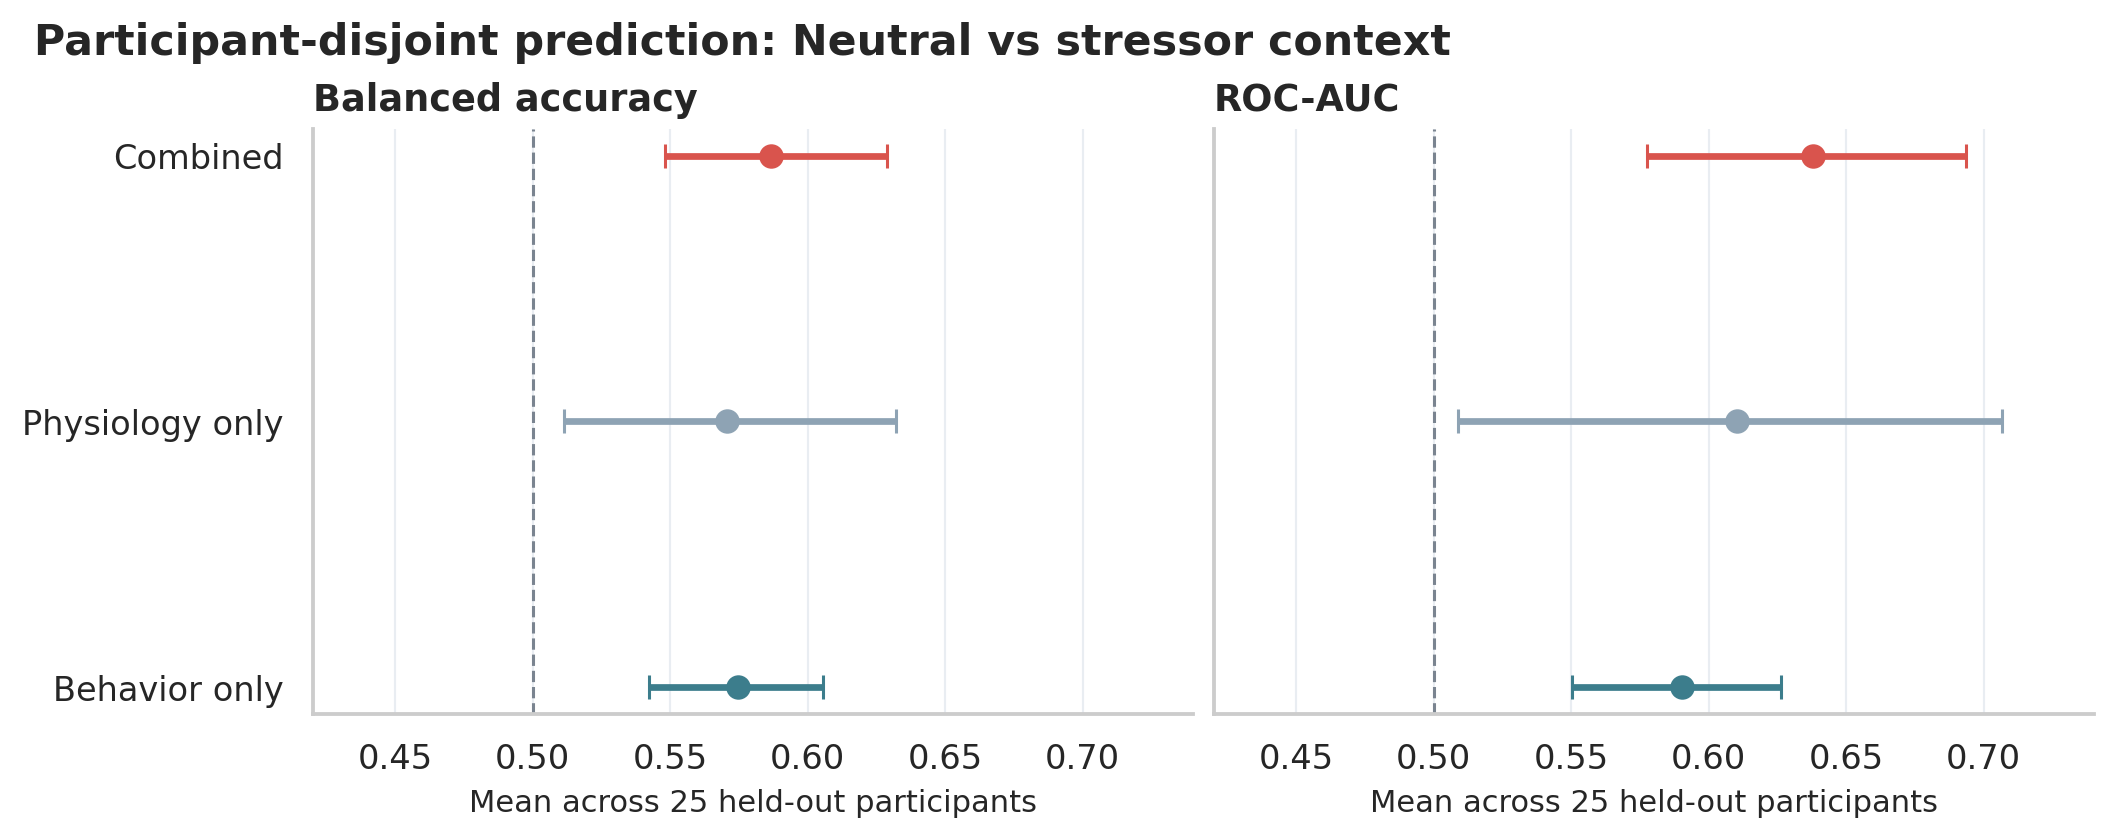

In [5]:
from IPython.display import Image, display
display(Image(filename=str(ROOT / "figures" / "model_comparison.png"), width=900))